# 00 - Kesifsel Veri Analizi (EDA)

**Proje:** Cho2017 Motor Imgeleme EEG Karsilastirmasi (CSP+LDA vs EEGNet vs ATCNet)

**Amac:** Modelleri egitmeden once veri kumesinin butunlugunu, denek/deneme yapisini, artefakt risklerini ve sinif ayristirilabilirligini incelemek.

**Arastirma sorusu baglami:** Sol vs sag el motor imgelemenin EEG'den ne kadar ogrenilebilir oldugunu ve deneklerarasi degiskenligi anlamak.

**Bu defter model EGITMEZ.** Ciktilar `results/eda/{figures,tables,reports}` altina kaydedilir.

> Not: Sunum kalitesindeki EDA ciktilarinin uretilmesi icin bu defteri sizin calistirmaniz gerekir.

In [1]:
# --- Ortak baslangic: proje koku kesfi ve ice aktarmalar ---
import sys, json, warnings
from pathlib import Path

def _find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (d / "pyproject.toml").exists() and (d / "src" / "cho2017_benchmark").exists():
            return d
    return p

ROOT = _find_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cho2017_benchmark import paths
from cho2017_benchmark.config import resolve_config, dump_resolved_config
from cho2017_benchmark.reproducibility import set_seed, save_environment

set_seed(42)
print("Proje koku:", paths.PROJECT_ROOT)

Proje koku: C:\Users\YIGIT-BASARAN\Downloads\bci


In [2]:
QUICK_MODE = False  # Yalnizca hata ayiklama icindir; bilimsel sonuc uretmez.
cfg = resolve_config(quick_mode=QUICK_MODE)
if cfg.quick_mode:
    print("UYARI: QUICK_MODE sonuclari nihai bilimsel sonuc olarak kullanilamaz.")
    print("QUICK_MODE denekleri:", cfg.active_subjects())
print("Aktif denek sayisi:", len(cfg.active_subjects()), "| Cihaz politikasi:", cfg.device)
print("Siniflar:", cfg.class_names, "| Ornekleme:", cfg.srate_in, "->", cfg.srate_out, "Hz")

# Cozulmus .mat yerlesimi ve paylasilan split manifestosu (sonraki hucreler bunlari kullanir).
from cho2017_benchmark.data.inspect_mat import load_layout_resolution
resolution = load_layout_resolution()
print("Layout dogrulandi mi:", resolution["validated"], "| yonelim:", resolution["orientation"])

_split_path = paths.manifests_dir() / "split_manifest.csv"
split_manifest = pd.read_csv(_split_path) if _split_path.exists() else None
if split_manifest is None:
    print("UYARI: split_manifest.csv yok; J bolumu icin once scripts/create_splits.py calistirin.")
else:
    print("Split manifestosu:", split_manifest.shape, "| denek:", split_manifest.subject_id.nunique())

Aktif denek sayisi: 50 | Cihaz politikasi: auto
Siniflar: ('left_hand', 'right_hand') | Ornekleme: 512 -> 256 Hz
Layout dogrulandi mi: True | yonelim: channels_by_time
Split manifestosu: (10120, 11) | denek: 50


## Bilimsel arka plan (Turkce)

1. **Veri kumesi motivasyonu:** Cho2017 (GigaDB 100295), 52 saglikli katilimcidan kaydedilen 64 kanalli EEG + 4 kanalli EMG motor imgeleme veri kumesidir.
2. **Motor imgeleme (MI):** Hareketi gerceklestirmeden zihinde canlandirma; sensorimotor ritimlerde (mu 8-13 Hz, beta 13-30 Hz) kontralateral guc degisimleri (ERD/ERS) olusturur.
3. **Sol/sag el siniflandirma:** Kontralateral motor korteks aktivasyonu (sol el -> sag yarimkure, C4; sag el -> sol yarimkure, C3) ayirt edici bilgidir.
4. **EEG vs EMG:** EEG beyin sinyalidir; EMG kas sinyalidir. EMG **asla** siniflandirma girdisi olarak kullanilmaz; yalnizca artefakt analizi icin tutulur (kas sizintisi tehlikesini gostermek icin).
5. **Deney protokolu:** Her sinif icin surekli kayit; `imagery_event` ile isaretlenen ~7 s'lik denemeler (uyarandan once 2 s, sonra 5 s). Imgeleme penceresi 0-3 s.
6. **Kanal duzeni:** Standart 10-10 (64 EEG). C3/C4/Cz sensorimotor analiz icin onemlidir.
7. **Deneme yapisi:** Sinif basina 100 veya 120 deneme; 5 veya 6 kosu (run).
8. **Artefakt riskleri:** Yuksek genlik (voltaj) ve EMG-korelasyonlu denemeler veri kumesinde `bad_trial_indices` ile isaretlenmistir; s29 ve s34 (>%90 EMG-korelasyonlu) ana analizden cikarilir.
9. **Denek degiskenligi:** MI performansi katilimcilar arasinda cok degisir; bazi denekler 'BCI-illiterate'.
10. **Sonraki deneyler:** CSP+LDA, EEGNet ve ATCNet ayni split ve girdi ile karsilastirilacak.

## A. Veri butunlugu
Indirilen dosyalar, eksik/bozuk dosyalar, alanlar, ornekleme tutarliligi, kanal sayisi, NaN/Inf kontrolu.

In [3]:
from cho2017_benchmark.data import download as dl
from cho2017_benchmark.data import prepare

fm_path = paths.manifests_dir() / "file_manifest.csv"
file_manifest = pd.read_csv(fm_path) if fm_path.exists() else pd.DataFrame()
n_downloaded = int((file_manifest.get("validation_status", pd.Series(dtype=str)) == "ok").sum()) if len(file_manifest) else 0
print("Dogrulanan indirilmis dosya sayisi:", n_downloaded, "/ 52")

rows = []
for idx in cfg.active_subjects(include_excluded=True):
    sid = f"s{idx:02d}"
    p = paths.subject_processed_path(sid)
    rec = None
    if p.exists():
        rec = prepare.load_processed(idx)
    rows.append({
        "subject_id": sid,
        "raw_present": (paths.raw_dir() / f"{sid}.mat").exists(),
        "processed_present": p.exists(),
        "n_trials": int(rec["y"].shape[0]) if rec is not None else 0,
        "srate": int(rec["sampling_rate"]) if rec is not None else None,
        "n_channels": int(rec["X_eeg"].shape[1]) if rec is not None else None,
        "has_nan": bool(np.isnan(rec["X_eeg"]).any()) if rec is not None else None,
        "has_inf": bool(np.isinf(rec["X_eeg"]).any()) if rec is not None else None,
    })
integrity = pd.DataFrame(rows)
(paths.eda_dir() / "tables").mkdir(parents=True, exist_ok=True)
integrity.to_csv(paths.eda_dir() / "tables" / "dataset_integrity.csv", index=False)
print("srate tutarli:", integrity["srate"].dropna().nunique() <= 1,
      "| kanal tutarli:", integrity["n_channels"].dropna().nunique() <= 1)
integrity.head()

Dogrulanan indirilmis dosya sayisi: 52 / 52


srate tutarli: True | kanal tutarli: True


,subject_id,raw_present,processed_present,n_trials,srate,n_channels,has_nan,has_inf
0,s01,True,True,200,256,64,False,False
1,s02,True,True,200,256,64,False,False
2,s03,True,True,200,256,64,False,False
3,s04,True,True,200,256,64,False,False
4,s05,True,True,200,256,64,False,False


## B. Katilimci ve deneme genel bakisi
Toplam/dahil/cikarilan katilimcilar, sinif basina denemeler, artefakt oncesi/sonrasi, 5 vs 6 kosu.

In [4]:
trial_manifest = pd.read_csv(paths.manifests_dir() / "trial_manifest.csv")
overview = (trial_manifest.groupby(["subject_id", "class_label"])
            .agg(n_total=("trial_id", "size"), n_included=("included", "sum")).reset_index())
overview.to_csv(paths.eda_dir() / "tables" / "subject_trial_counts.csv", index=False)
runs = trial_manifest.groupby("subject_id")["run_id"].nunique()
print("Kosu sayisi dagilimi:\n", runs.value_counts())
print("Calisma yontemi (run_id_source) dagilimi:\n", trial_manifest["run_id_source"].value_counts())
overview.head()

Kosu sayisi dagilimi:
 run_id
5    47
6     3
Name: count, dtype: int64
Calisma yontemi (run_id_source) dagilimi:
 run_id_source
inferred_from_protocol    10120
Name: count, dtype: int64


,subject_id,class_label,n_total,n_included
0,s01,left_hand,100,100
1,s01,right_hand,100,100
2,s02,left_hand,100,99
3,s02,right_hand,100,100
4,s03,left_hand,100,100


## C. Kotu deneme analizi
Denek/sinif/neden bazinda kotu denemeler; s29 ve s34 ozel incelemesi.

In [5]:
ex_path = paths.manifests_dir() / "excluded_trials.csv"
excluded = pd.read_csv(ex_path) if ex_path.exists() else pd.DataFrame(columns=["subject_id","exclusion_reason"])
if len(excluded):
    by_subject = excluded.groupby("subject_id").size().rename("n_excluded")
    by_reason = excluded["exclusion_reason"].value_counts()
else:
    by_subject = pd.Series(dtype=int, name="n_excluded"); by_reason = pd.Series(dtype=int)
bad_summary = by_subject.reset_index()
bad_summary.to_csv(paths.eda_dir() / "tables" / "bad_trial_summary.csv", index=False)
print("Neden bazinda kotu denemeler:\n", by_reason)

# s29 / s34 ozel inceleme (EDA'da tutulurlar)
for idx in (29, 34):
    sid = f"s{idx:02d}"
    p = paths.subject_processed_path(sid)
    if p.exists():
        rec = prepare.load_processed(idx)
        print(f"{sid}: toplam={rec['y'].shape[0]}, dahil={int(rec['included'].sum())}, "
              f"EMG-kotu={int(rec['bad_emg'].sum())}, voltaj-kotu={int(rec['bad_amplitude'].sum())}")
    else:
        print(f"{sid}: islenmis dosya yok (prepare --subjects {idx} ile uretin).")

Neden bazinda kotu denemeler:
 exclusion_reason
emg_correlation              382
amplitude                     29
amplitude;emg_correlation      1
Name: count, dtype: int64
s29: toplam=200, dahil=21, EMG-kotu=179, voltaj-kotu=0
s34: toplam=200, dahil=16, EMG-kotu=184, voltaj-kotu=0


## D. Ham sinyal ornekleri
Temsili EEG (C3, C4, Cz) ve EMG kanallari; sol/sag denemeler. Genis bant icin ham `.mat` dosyalarindan birkac temsili denek yuklenir.

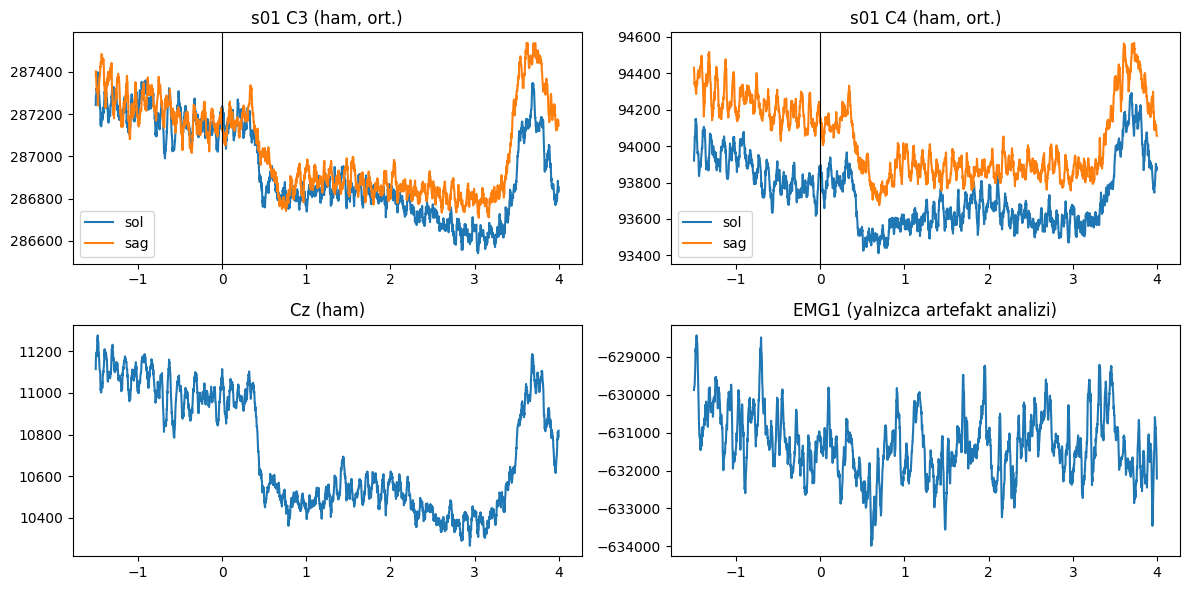

In [6]:
from cho2017_benchmark.data import loader, epoching
EEG_CH = loader.CHO2017_EEG_CHANNELS
def ch(name): return EEG_CH.index(name)

repr_subjects = [s for s in cfg.active_subjects()[:1]]  # temsili: ilk aktif denek
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for idx in repr_subjects:
    rec = loader.load_subject(idx, resolution=resolution)
    ep = epoching.epoch_subject(rec, tmin_s=float(cfg.get("epoch.tmin_s")), tmax_s=float(cfg.get("epoch.tmax_s")),
                                class_mapping=cfg.class_mapping, resolution=resolution)
    t = ep.epoch_times()
    left = ep.X_eeg[ep.class_label == "left_hand"]
    right = ep.X_eeg[ep.class_label == "right_hand"]
    for ax, cname in zip(axes[0], ["C3", "C4"]):
        ax.plot(t, left[:20, ch(cname)].mean(0), label="sol")
        ax.plot(t, right[:20, ch(cname)].mean(0), label="sag")
        ax.axvline(0, color="k", lw=0.8); ax.set_title(f"{rec.subject_id} {cname} (ham, ort.)"); ax.legend()
    axes[1, 0].plot(t, ep.X_eeg[:20, ch("Cz")].mean(0)); axes[1, 0].set_title("Cz (ham)")
    axes[1, 1].plot(t, ep.X_emg[:20, 0].mean(0)); axes[1, 1].set_title("EMG1 (yalnizca artefakt analizi)")
fig.tight_layout()
(paths.eda_dir() / "figures").mkdir(parents=True, exist_ok=True)
fig.savefig(paths.eda_dir() / "figures" / "raw_signal_examples.png", dpi=200, bbox_inches="tight")
plt.show()

## E. Genlik ve varyans analizi
Kanal bazli genlik dagilimi, deneme bazli tepe-tepe genligi, kanal varyansi, aykiri denekler.

C:\Users\YIGIT-BASARAN\AppData\Local\Temp\ipykernel_3356\1648884962.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.bar(quality["subject_id"], quality["ptp_median"]); ax.set_xticklabels(quality["subject_id"], rotation=90, fontsize=6)


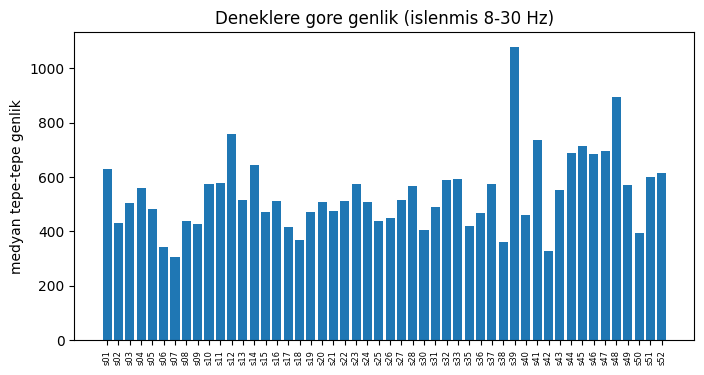

,subject_id,mean_abs,ptp_median,chan_var_mean
0,s01,93.066986,630.269897,15537.924805
1,s02,63.344646,430.598450,7694.261719
2,s03,74.464233,504.943604,9823.348633
3,s04,78.596359,561.188599,10754.072266
4,s05,68.934608,482.541748,8422.933594


In [7]:
rows = []
for idx in cfg.active_subjects():
    p = paths.subject_processed_path(f"s{idx:02d}")
    if not p.exists():
        continue
    rec = prepare.load_processed(idx)
    X = rec["X_eeg"][rec["included"]]
    rows.append({"subject_id": f"s{idx:02d}",
                 "mean_abs": float(np.abs(X).mean()),
                 "ptp_median": float(np.median(np.ptp(X, axis=2))),
                 "chan_var_mean": float(X.var(axis=2).mean())})
quality = pd.DataFrame(rows)
quality.to_csv(paths.eda_dir() / "tables" / "channel_quality_summary.csv", index=False)
if len(quality):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(quality["subject_id"], quality["ptp_median"]); ax.set_xticklabels(quality["subject_id"], rotation=90, fontsize=6)
    ax.set_ylabel("medyan tepe-tepe genlik"); ax.set_title("Deneklere gore genlik (islenmis 8-30 Hz)")
    fig.savefig(paths.eda_dir() / "figures" / "amplitude_by_subject.png", dpi=200, bbox_inches="tight")
    plt.show()
quality.head()

## F. Frekans alani analizi
Welch PSD, sinif bazli ortalama PSD, mu/beta bantlari, C3 vs C4. Genis bant PSD icin ham veriden temsili denek(ler) kullanilir.

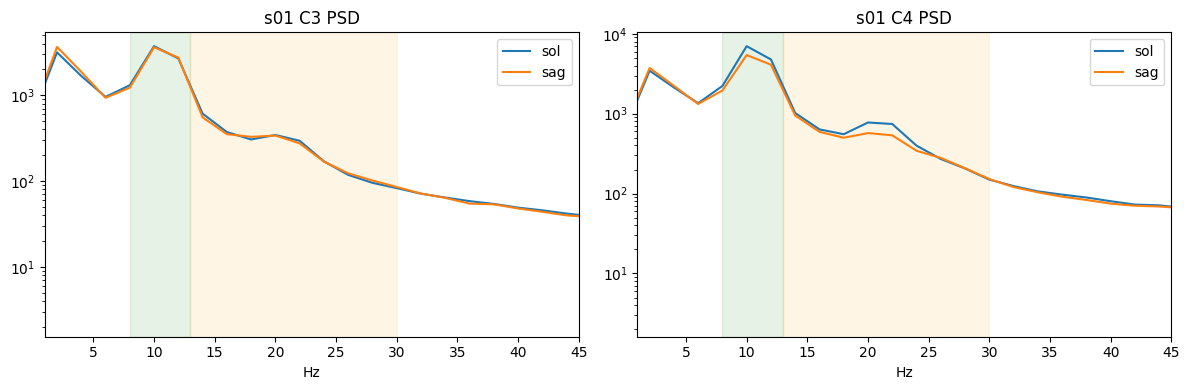

In [8]:
from scipy.signal import welch
def band_power(x, fs, lo, hi):
    f, pxx = welch(x, fs=fs, nperseg=min(256, x.shape[-1]))
    m = (f >= lo) & (f <= hi)
    return pxx[..., m].mean(axis=-1)

idx = cfg.active_subjects()[0]
rec = loader.load_subject(idx, resolution=resolution)
ep = epoching.epoch_subject(rec, tmin_s=0.0, tmax_s=3.0, class_mapping=cfg.class_mapping, resolution=resolution)
fs = rec.srate
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cname, ax in zip(["C3", "C4"], axes):
    for label, name in [(0, "sol"), (1, "sag")]:
        sig = ep.X_eeg[ep.y == label][:, ch(cname)]
        f, pxx = welch(sig, fs=fs, nperseg=256, axis=-1)
        ax.semilogy(f, pxx.mean(0), label=name)
    ax.axvspan(8, 13, alpha=0.1, color="green"); ax.axvspan(13, 30, alpha=0.1, color="orange")
    ax.set_xlim(1, 45); ax.set_title(f"{rec.subject_id} {cname} PSD"); ax.set_xlabel("Hz"); ax.legend()
fig.tight_layout()
fig.savefig(paths.eda_dir() / "figures" / "psd_c3_c4.png", dpi=200, bbox_inches="tight")
plt.show()

## G. Uzaysal analiz
Elektrot duzeni ve sinif bazli bant gucu topografik haritalari (sol-sag farki). mu/beta bantlari islenmis (8-30 Hz) onbellekten hesaplanir.

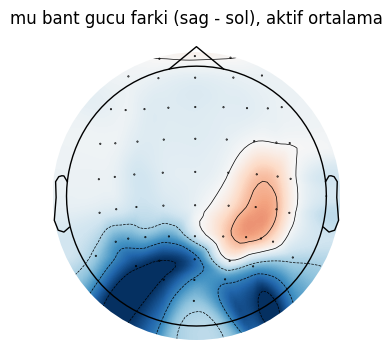

In [9]:
try:
    import mne
    info = mne.create_info(list(EEG_CH), sfreq=cfg.srate_out, ch_types="eeg")
    info.set_montage("standard_1005", on_missing="ignore")
    # Aktif deneklerde mu bant gucu farki (sag - sol)
    diff = np.zeros(len(EEG_CH)); n = 0
    for s in cfg.active_subjects():
        p = paths.subject_processed_path(f"s{s:02d}")
        if not p.exists():
            continue
        rec_p = prepare.load_processed(s)
        X = rec_p["X_eeg"]; y = rec_p["y"]; inc = rec_p["included"]
        bp = band_power(X, cfg.srate_out, 8, 13)  # (n_trials, 64)
        diff += bp[(y == 1) & inc].mean(0) - bp[(y == 0) & inc].mean(0); n += 1
    if n:
        diff /= n
        fig, ax = plt.subplots(figsize=(5, 4))
        mne.viz.plot_topomap(diff, info, axes=ax, show=False)
        ax.set_title("mu bant gucu farki (sag - sol), aktif ortalama")
        fig.savefig(paths.eda_dir() / "figures" / "topomap_mu_right_minus_left.png", dpi=200, bbox_inches="tight")
        plt.show()
except Exception as e:
    print("Topomap atlandi (mne gerekli):", e)

## H. ERD/ERS analizi
Yeterli uyaran-oncesi temel (baseline) var (~2 s). Temel -0.5..0 s ile mu bandinda ERD/ERS hesaplanir. Temel yoksa gorev-donemi goreli bant gucu gosterilir.

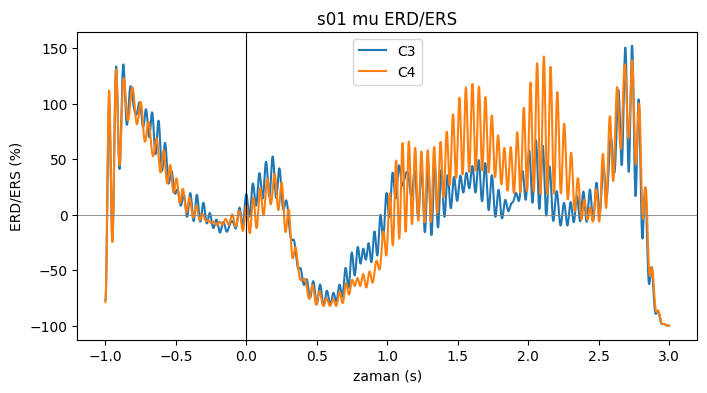

In [10]:
from scipy.signal import butter, sosfiltfilt
if resolution.get("pre_stimulus_available"):
    idx = cfg.active_subjects()[0]
    rec = loader.load_subject(idx, resolution=resolution)
    ep = epoching.epoch_subject(rec, tmin_s=-1.0, tmax_s=3.0, class_mapping=cfg.class_mapping, resolution=resolution)
    t = ep.epoch_times()
    sos = butter(4, [8, 13], btype="band", fs=rec.srate, output="sos")
    env = sosfiltfilt(sos, ep.X_eeg, axis=-1) ** 2
    base = env[:, :, (t >= -0.5) & (t < 0)].mean(axis=2, keepdims=True)
    erd = (env - base) / base * 100.0
    fig, ax = plt.subplots(figsize=(8, 4))
    for cname in ["C3", "C4"]:
        ax.plot(t, erd[:, ch(cname)].mean(0), label=cname)
    ax.axvline(0, color="k", lw=0.8); ax.axhline(0, color="grey", lw=0.6)
    ax.set_xlabel("zaman (s)"); ax.set_ylabel("ERD/ERS (%)"); ax.set_title(f"{rec.subject_id} mu ERD/ERS"); ax.legend()
    fig.savefig(paths.eda_dir() / "figures" / "erd_ers.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Uyaran-oncesi temel yok; ERD/ERS yerine gorev-donemi goreli guc kullanilmali.")

## I. Sinif ayristirilabilirligi
Egitimden bagimsiz betimleyici ozellikler (C3/C4 mu/beta gucu) ile basit gorsellestirme. (EDA'da siniflandirici ayarlanmaz.)

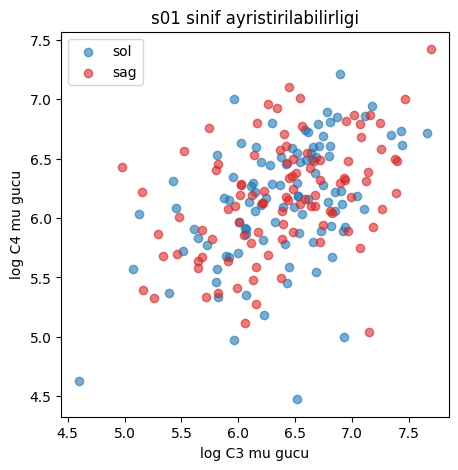

In [11]:
idx = cfg.active_subjects()[0]
rec_p = prepare.load_processed(idx)
X, y, inc = rec_p["X_eeg"], rec_p["y"], rec_p["included"]
c3_mu = band_power(X[:, ch("C3")], cfg.srate_out, 8, 13)
c4_mu = band_power(X[:, ch("C4")], cfg.srate_out, 8, 13)
feat = np.log(np.c_[c3_mu, c4_mu] + 1e-12)
fig, ax = plt.subplots(figsize=(5, 5))
for label, name, c in [(0, "sol", "tab:blue"), (1, "sag", "tab:red")]:
    m = (y == label) & inc
    ax.scatter(feat[m, 0], feat[m, 1], alpha=0.6, label=name, color=c)
ax.set_xlabel("log C3 mu gucu"); ax.set_ylabel("log C4 mu gucu")
ax.set_title(f"s{idx:02d} sinif ayristirilabilirligi"); ax.legend()
fig.savefig(paths.eda_dir() / "figures" / "class_separability.png", dpi=200, bbox_inches="tight")
plt.show()

## J. Split incelemesi
Train/validation/test sayilari, kosu-temelli split gorsellestirmesi, sinif dengesi, deneme ortusmesi olmadigi dogrulamasi.

In [12]:
from cho2017_benchmark.data import splits as splits_mod
splits_mod.assert_no_leakage(split_manifest, excluded_subjects=cfg.excluded_subjects)
summary = splits_mod.split_summary_table(split_manifest)
summary.to_csv(paths.eda_dir() / "tables" / "split_summary.csv", index=False)
print("Sizinti kontrolu: GECTI")
print("Split yontemi dagilimi:", summary["split_method"].value_counts().to_dict())
summary.head()

Sizinti kontrolu: GECTI
Split yontemi dagilimi: {'run_holdout': 50}


,subject_id,split_method,train_left,train_right,val_left,val_right,test_left,test_right,n_excluded,n_total
0,s01,run_holdout,60,60,20,20,20,20,0,200
1,s02,run_holdout,60,60,20,20,19,20,1,200
2,s03,run_holdout,60,60,20,20,20,20,0,200
3,s04,run_holdout,60,60,20,20,20,20,0,200
4,s05,run_holdout,59,60,20,20,20,20,1,200


## K. EDA sonuclari
- Neler ogrenilebilir gorunuyor (kontralateral mu/beta ERD).
- Hangi denekler zor olabilir (zayif ERD, yuksek artefakt).
- Artefakt sizintisi nerede olabilir (EMG; s29/s34).
- Beklenen performans degiskenligi (deneklerarasi genis).
- Uc model icin cikarimlar.

In [13]:
lines = ["# Cho2017 EDA ozeti\n",
         f"- Dogrulanan indirilmis dosya: {n_downloaded}/52",
         f"- Islenmis denek: {int(integrity['processed_present'].sum())}",
         f"- srate tutarli: {integrity['srate'].dropna().nunique() <= 1}",
         f"- Split yontemleri: {summary['split_method'].value_counts().to_dict()}",
         f"- Cikarilan denekler (model): {list(cfg.excluded_subjects)}",
         "",
         "QUICK_MODE etkinse sonuclar bilimsel degildir."]
(paths.eda_dir() / "reports").mkdir(parents=True, exist_ok=True)
(paths.eda_dir() / "reports" / "dataset_summary.md").write_text("\n".join(lines), encoding="utf-8")
print("dataset_summary.md yazildi.")

dataset_summary.md yazildi.


## Limitations (Sinirliliklar)
- Katilimci basina tek oturum: gercek oturumlar-arasi genelleme calismasi degildir.
- Kosu kimlikleri acik degildir; protokol sirasindan cikarilmistir (kronolojik depolama varsayimi).
- MI performansi deneklerarasi cok degiskendir.
- EMG-temelli denek cikarimi tum artefakt sizintisini ortadan kaldirmaz.
- Cevrimdisi test dogrulugu cevrimici BCI kullanilabilirligine esit degildir.

## Generated Files (Uretilen Dosyalar)
- `results/eda/tables/{dataset_integrity,subject_trial_counts,bad_trial_summary,channel_quality_summary,split_summary}.csv`
- `results/eda/figures/*.png`
- `results/eda/reports/dataset_summary.md`

In [14]:
expected = [paths.eda_dir() / "tables" / "dataset_integrity.csv",
            paths.eda_dir() / "tables" / "split_summary.csv",
            paths.eda_dir() / "reports" / "dataset_summary.md"]
missing = [str(p) for p in expected if not p.exists()]
assert not missing, f"Beklenen EDA ciktilari eksik: {missing}"
print("Tum beklenen EDA ciktilari mevcut.")

Tum beklenen EDA ciktilari mevcut.
